<a href="https://colab.research.google.com/github/akuntugasrapon/RafkiAhmadPagamanda_2311533016_ML2526/blob/main/Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [4]:
DATA_PATH = "advertising.csv"  # sesuaikan path

df = pd.read_csv(DATA_PATH)

# pisahkan fitur dan target
X = df.drop("Sales", axis=1)
y = df["Sales"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

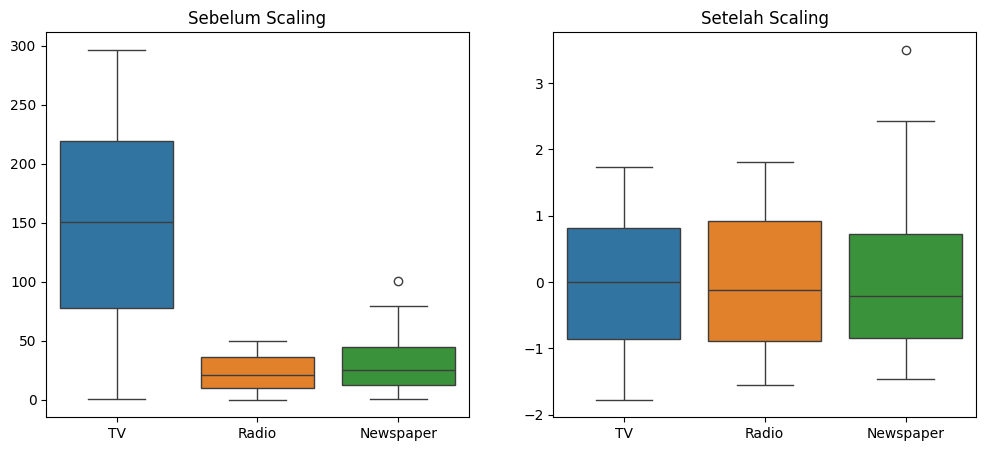

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# sebelum scaling
sns.boxplot(data=X_train[['TV','Radio','Newspaper']], ax=ax[0])
ax[0].set_title("Sebelum Scaling")

# setelah scaling
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
sns.boxplot(data=X_train_scaled_df[['TV','Radio','Newspaper']], ax=ax[1])
ax[1].set_title("Setelah Scaling")

plt.show()

In [7]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_train_lr = lr.predict(X_train_scaled)
y_pred_test_lr = lr.predict(X_test_scaled)

rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_test_lr))

print("Linear Regression")
print("RMSE Train:", rmse_train_lr)
print("RMSE Test :", rmse_test_lr)
print("Coefficients:", lr.coef_)

Linear Regression
RMSE Train: 1.6358920055378559
RMSE Test : 1.7052146229349234
Coefficients: [4.58720774 1.48984025 0.08791597]


In [8]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_train_ridge = ridge.predict(X_train_scaled)
y_pred_test_ridge = ridge.predict(X_test_scaled)

rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("\nRidge Regression (alpha=1.0)")
print("RMSE Train:", rmse_train_ridge)
print("RMSE Test :", rmse_test_ridge)
print("Coefficients:", ridge.coef_)


Ridge Regression (alpha=1.0)
RMSE Train: 1.6361615871481856
RMSE Test : 1.7074302367919385
Coefficients: [4.55913661 1.48074139 0.0914114 ]


In [9]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_train_lasso = lasso.predict(X_train_scaled)
y_pred_test_lasso = lasso.predict(X_test_scaled)

rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_test_lasso))

print("\nLasso Regression (alpha=0.1)")
print("RMSE Train:", rmse_train_lasso)
print("RMSE Test :", rmse_test_lasso)
print("Coefficients:", lasso.coef_)


Lasso Regression (alpha=0.1)
RMSE Train: 1.643031487122971
RMSE Test : 1.7117675228539946
Coefficients: [4.49218143 1.42301597 0.01566227]


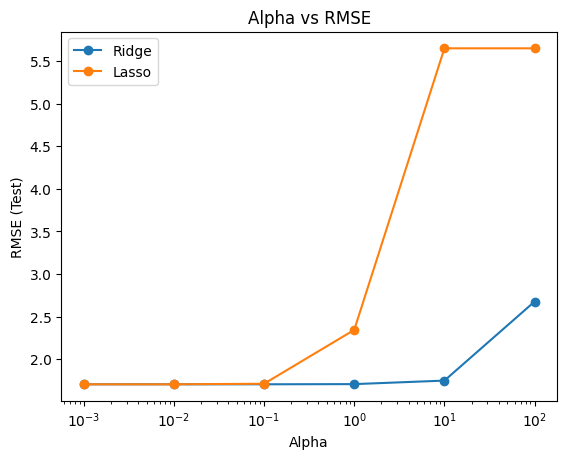

In [10]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_rmse = []
lasso_rmse = []

for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

# plot
plt.plot(alphas, ridge_rmse, marker='o', label='Ridge')
plt.plot(alphas, lasso_rmse, marker='o', label='Lasso')

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.title("Alpha vs RMSE")
plt.legend()
plt.show()

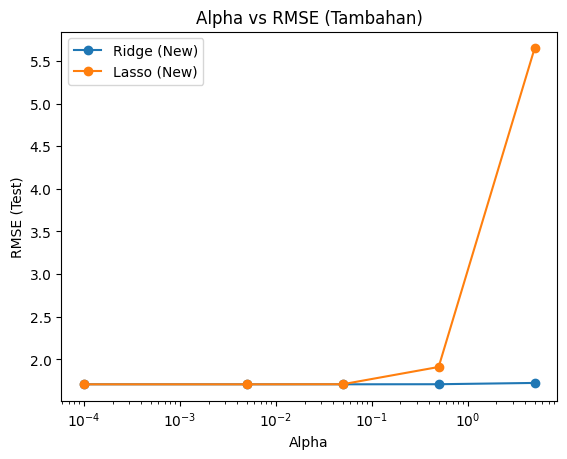

In [13]:
# Step 3a - Tambahan nilai alpha baru
alphas_new = [0.0001, 0.005, 0.05, 0.5, 5]

ridge_rmse_new = []
lasso_rmse_new = []

for a in alphas_new:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse_new.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse_new.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

# plot hasil baru
plt.plot(alphas_new, ridge_rmse_new, marker='o', label='Ridge (New)')
plt.plot(alphas_new, lasso_rmse_new, marker='o', label='Lasso (New)')

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("RMSE (Test)")
plt.title("Alpha vs RMSE (Tambahan)")
plt.legend()
plt.show()

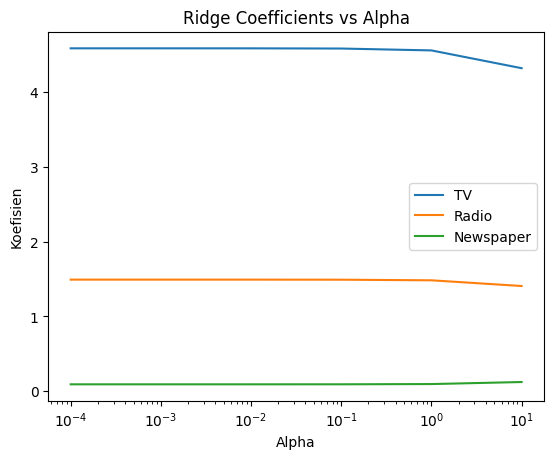

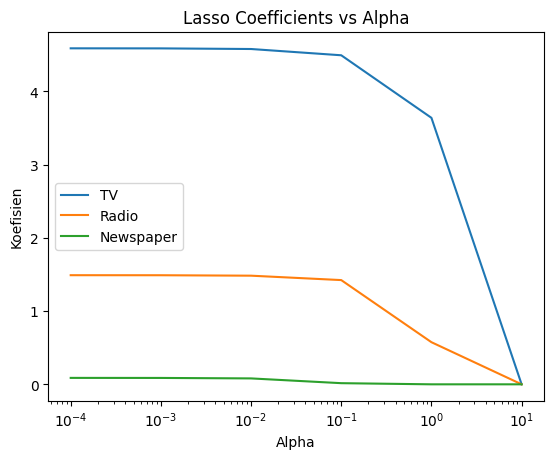

In [14]:
# Step 3b - Grafik koefisien vs alpha

alphas_coef = [0.0001, 0.001, 0.01, 0.1, 1, 10]

coefs_ridge = []
coefs_lasso = []

for a in alphas_coef:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    coefs_ridge.append(r.coef_)
    coefs_lasso.append(l.coef_)

coefs_ridge = np.array(coefs_ridge)
coefs_lasso = np.array(coefs_lasso)

# Plot Ridge
for i in range(coefs_ridge.shape[1]):
    plt.plot(alphas_coef, coefs_ridge[:, i], label=X.columns[i])

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Koefisien")
plt.title("Ridge Coefficients vs Alpha")
plt.legend()
plt.show()

# Plot Lasso
for i in range(coefs_lasso.shape[1]):
    plt.plot(alphas_coef, coefs_lasso[:, i], label=X.columns[i])

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Koefisien")
plt.title("Lasso Coefficients vs Alpha")
plt.legend()
plt.show()